

<h1 style="text-align: center; font-family: 'Helvetica Neue', Arial, sans-serif; color: #1a365d; font-weight: bold; letter-spacing: 1px;">
    TS2
</h1>



<div style="text-align: center; font-family: 'Segoe UI', Helvetica, Arial, sans-serif; font-size: 16px;">
<b>Nombre y apellido:</b> Irina Polack



</div>


En este trabajo vamos a analizar el comportamiento de un ADC, cambiando la relación entre la potencia de ruido y la potencia de cuantización, $P_n=k_n.P_q$, siendo $P_q$ la potencia de cuantización, $P_q=\frac{q^2}{12}$, $k_n$ un factor de escala que me muestra la relación entre las potencias (el cual se va a variar en 1, 0.1 y 10) y $P_n$ es la esperanza de su cuadrado.
$q=\frac{2Vref}{2^b}$, siendo b la cantidad de bits que para el análisis vamos a variar entre 4, 8 y 16.

La señal analógica de entrada va a ser:
$$x[n] = Vref\sin(\frac{2π \cdot ff \cdot n}{fs} + Φ)$$.

Teniendo un número de frecuencia de muestreo igual a 1000 (fs)

Un número de muestras fija igual a 1000 (N)

frecuencia fija igual a 1 Hz (ff)

Siendo Vmáx el valor máximo del voltaje, en este caso fijado a  $\sqrt{2}$

Φ el desplazamiento angular, en este caso igual a 0

n la variable que va desde 0 a N-1

Para el análisis del ruido vamos a utilizar la autocorrelación:
$$r_{xx}[l] = \sum_{n=-N}^{N-1} x[n] \, x[n + l]$$
Se dice que una señal es incorrelada si su autocorrelación es   $$r_{xx}[l] = \begin{cases} E, & \text{para } l = 0 \\ 0, & \text{para } l \neq 0 \end{cases}$$, quedando:
$$E \cdot \delta[l]$$
siendo E la energía de la señal.
A este tipo de ruidos incorrelados se les llama ruido blanco. En este trabajo se busca ver en que casos tenemos ruido blanco y en cuales no.
Por último vamos a analizar la distribución del error de cuantización a través de su histograma y un ktest, el cual nos va a decir si se rechaza la hipótesis de la distribución uniforme del error o si no hay suficiente evidencia para descartarla.


 Cálculo de la SNR

La potencia de la señal está normalizada, por lo tanto:

$$
P_s = 1
$$

El paso de cuantización para un ADC de $B$ bits y rango analógico
$[-V_F,V_F]$ es:

$$
q = \frac{2V_F}{2^B}
$$

Como $V_F=2$ V:

$$
q = \frac{4}{2^B}
$$

La potencia del ruido de cuantización es:

$$
P_q = \frac{q^2}{12}
$$

Entonces:

$$
P_q
= \frac{1}{12}
\left(\frac{4}{2^B}\right)^2
= \frac{16}{12\,2^{2B}}
= \frac{4}{3\,4^B}
$$

La potencia del ruido agregado está definida por:

$$
P_n = k_n P_q
$$

Por lo tanto, la potencia de ruido total es:

$$
P_{\text{ruido}}
= P_q + P_n
$$

$$
P_{\text{ruido}}
= P_q + k_nP_q
= (1+k_n)P_q
$$

Reemplazando $P_q$:

$$
P_{\text{ruido}}
= (1+k_n)\frac{4}{3\,4^B}
$$

La relación señal-ruido (SNR) se define como:

$$
SNR = \frac{P_s}{P_{\text{ruido}}}
$$

Como $P_s=1$:

$$
SNR
= \frac{1}{(1+k_n)\frac{4}{3\,4^B}}
$$

Por lo tanto:

$$
\boxed{
SNR = \frac{3\,4^B}{4(1+k_n)}
}
$$

Para expresar la SNR en decibeles:

$$
SNR_{dB}
=10\log_{10}(SNR)
$$

$$
\boxed{
SNR_{dB}
=
10\log_{10}
\left(
\frac{3\,4^B}{4(1+k_n)}
\right)
}
$$

Separando los términos:

$$
SNR_{dB}
=
10\log_{10}\left(\frac{3}{4}\right)
+
10B\log_{10}(4)
-
10\log_{10}(1+k_n)
$$

Como:

$$
10\log_{10}(4)\approx 6.02
$$

y

$$
10\log_{10}\left(\frac{3}{4}\right)\approx -1.25
$$

obtenemos finalmente:

$$
\boxed{
SNR_{dB}
\approx
6.02B-1.25
-10\log_{10}(1+k_n)
}
$$

siendo B la cantidad de bits, veremos si la relación entre el SNR teórico y el calculado es igual o no.


<b> Caso 1: $k_n=1$ b={4, 8, 16} </b>


        SIMULACIÓN CON 4 BITS
q = 2.500000e-01 V
Pq teórica = 5.208333e-03 V²
Pn = 5.208333e-03 V²


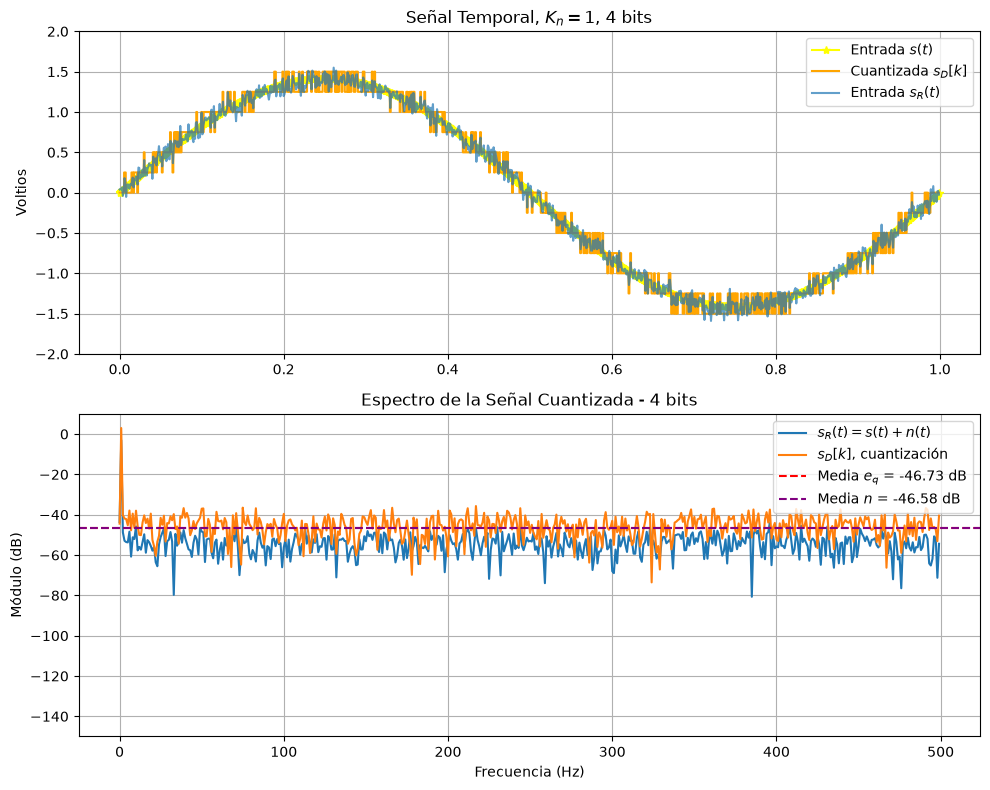

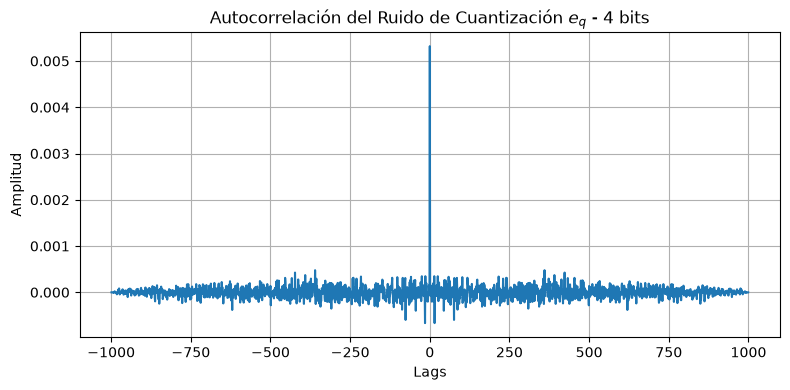

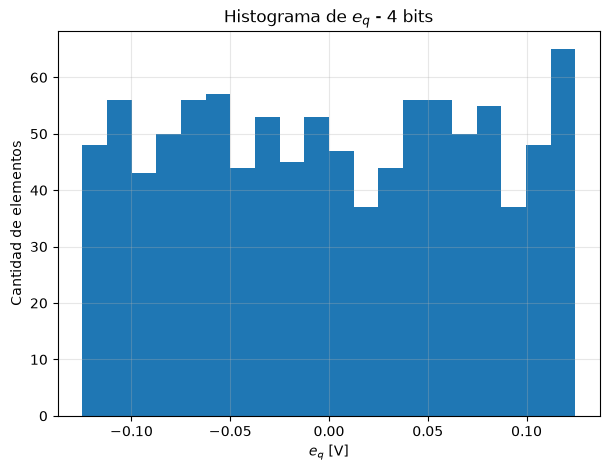


--- Análisis Estadístico ---
Varianza de e_q medida: 5.32e-03 V²
Varianza teórica Pq: 5.21e-03 V²
Estadístico KS: 0.0200
p-value: 0.8116
Resultado: No se rechaza H0. El ruido de cuantización es compatible con U(-q/2, q/2).
SNR Real del sistema: 19.47 dB

        SIMULACIÓN CON 8 BITS
q = 1.562500e-02 V
Pq teórica = 2.034505e-05 V²
Pn = 2.034505e-05 V²


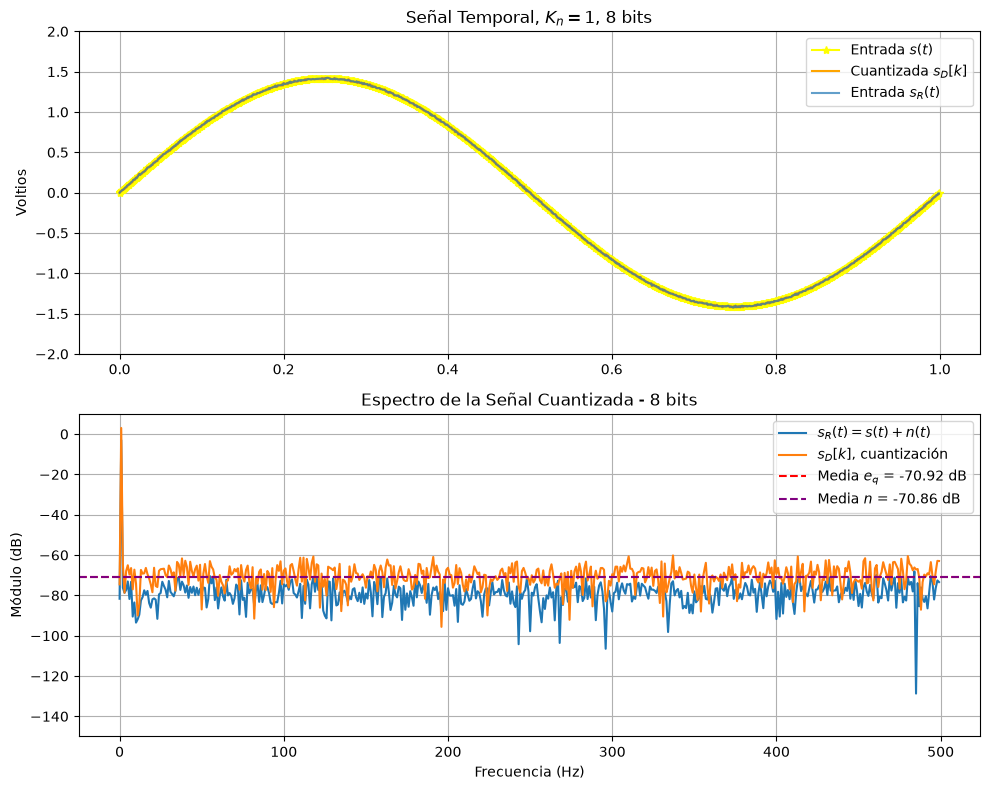

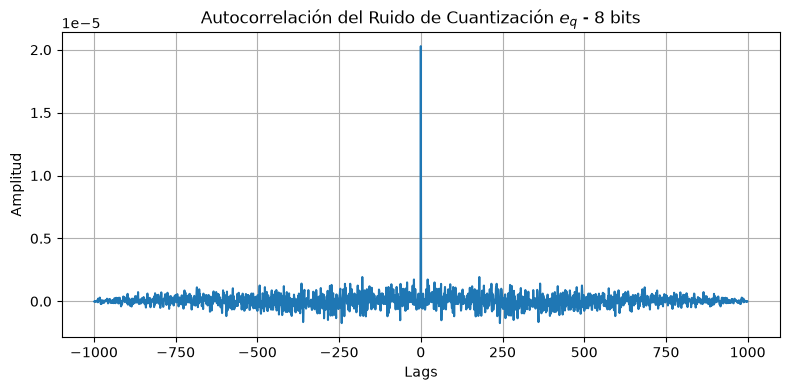

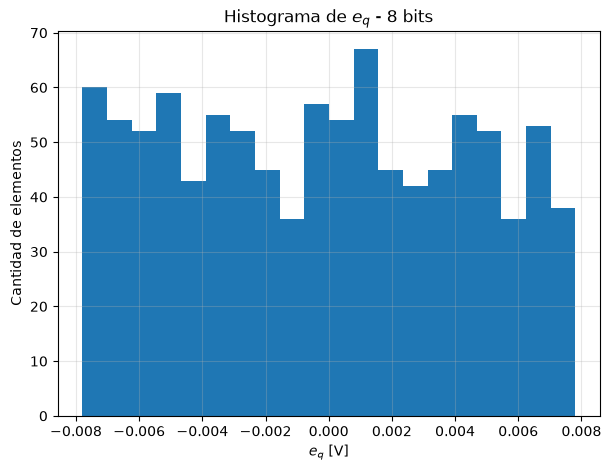


--- Análisis Estadístico ---
Varianza de e_q medida: 2.02e-05 V²
Varianza teórica Pq: 2.03e-05 V²
Estadístico KS: 0.0357
p-value: 0.1533
Resultado: No se rechaza H0. El ruido de cuantización es compatible con U(-q/2, q/2).
SNR Real del sistema: 44.09 dB

        SIMULACIÓN CON 16 BITS
q = 6.103516e-05 V
Pq teórica = 3.104409e-10 V²
Pn = 3.104409e-10 V²


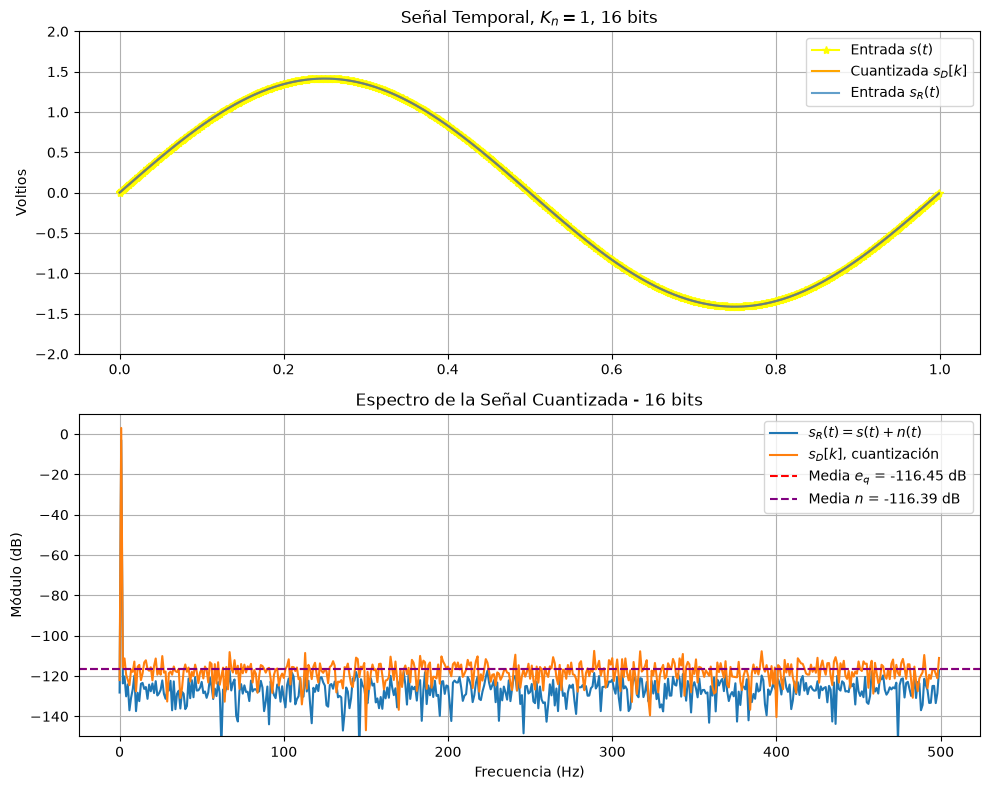

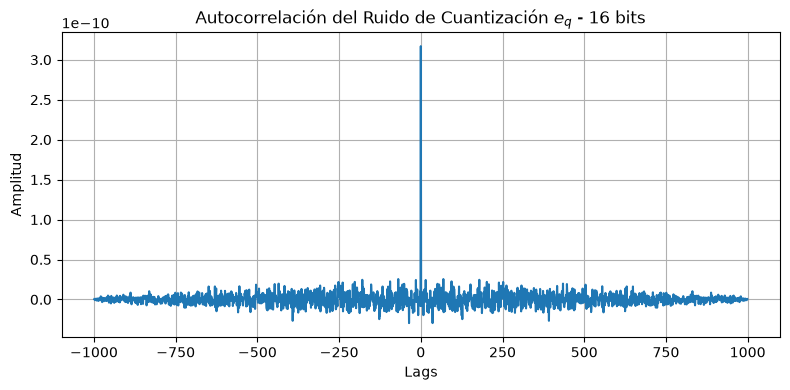

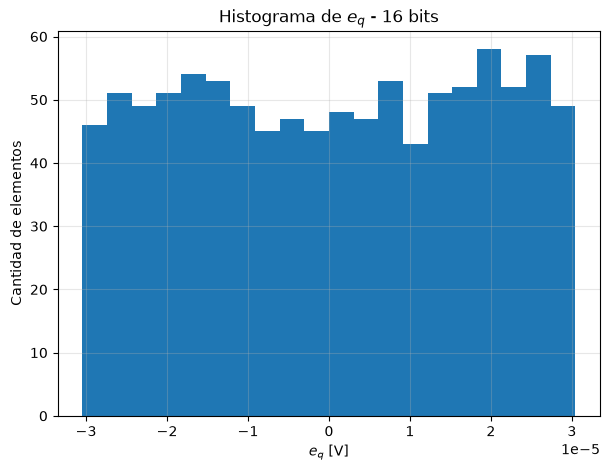


--- Análisis Estadístico ---
Varianza de e_q medida: 3.17e-10 V²
Varianza teórica Pq: 3.10e-10 V²
Estadístico KS: 0.0267
p-value: 0.4660
Resultado: No se rechaza H0. El ruido de cuantización es compatible con U(-q/2, q/2).
SNR Real del sistema: 92.09 dB


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import kstest


# %% 1. Definición de la función senoidal
def funcion_sen(A=1, Vmed=0, ff=1, phi=0, nn=1000, fs=1000):
    tt = np.arange(nn) / fs
    xx = A * np.sin(2 * np.pi * ff * tt + phi) + Vmed
    return tt, xx


# %% 2. Parámetros de la simulación
fs = 1000
N = 1000

B = [4, 8, 16]

Vf = 2.0
kn = 1
f0 = 1.0


# %% 3. Simulación para cada cantidad de bits
for b in B:

    print("\n======================================")
    print(f"        SIMULACIÓN CON {b} BITS")
    print("======================================")

    # Paso de cuantización
    q = (2 * Vf) / (2**b)

    # Potencia teórica del ruido de cuantización
    Pq = (q**2) / 12

    # Potencia del ruido analógico
    Pn = kn * Pq

    print(f"q = {q:.6e} V")
    print(f"Pq teórica = {Pq:.6e} V²")
    print(f"Pn = {Pn:.6e} V²")


    # %% 4. Generación de la señal
    tt, s = funcion_sen(
        A=np.sqrt(2),
        Vmed=0,
        ff=f0,
        phi=0,
        nn=N,
        fs=fs
    )

    # Ruido analógico
    sigma_n = np.sqrt(Pn)
    n = np.random.normal(0, sigma_n, N)

    # Señal con ruido
    s_R = s + n

    # Saturación
    s_R_sat = np.clip(s_R, -Vf, Vf)

    # Cuantización
    s_D = np.round(s_R_sat / q) * q

    # Error de cuantización
    e_q = s_D - s_R


    # %% 5. Análisis espectral
    S_D = np.fft.fft(s_D) / N
    S_s = np.fft.fft(s) / N
    S_r = np.fft.fft(s_R) / N
    e = np.fft.fft(e_q) / N
    r = np.fft.fft(n) / N

    freqs = np.fft.fftfreq(N, 1/fs)

    # Frecuencias positivas
    half_N = N // 2

    S_D_onesided = S_D[:half_N].copy()
    S_s_onesided = S_s[:half_N].copy()
    S_r_onesided = S_r[:half_N].copy()
    e_onesided = e[:half_N].copy()
    r_onesided = r[:half_N].copy()

    freqs_oneside = freqs[:half_N]

    # Corrección de amplitud unilateral
    S_D_onesided[1:] *= 2
    S_s_onesided[1:] *= 2
    e_onesided[1:] *= 2
    r_onesided[1:] *= 2

    # Módulos en dB
    mod_S_D_dB = 20 * np.log10(np.abs(S_D_onesided) + 1e-12)
    mod_S_s_dB = 20 * np.log10(np.abs(S_s_onesided) + 1e-12)
    mod_S_r_dB = 20 * np.log10(np.abs(S_r_onesided) + 1e-12)
    mod_r_dB = 20 * np.log10(np.abs(r_onesided) + 1e-12)
    mod_e_dB = 20 * np.log10(np.abs(e_onesided) + 1e-12)

    # Promedio espectral correcto (sobre la potencia media)
    mediaq = 10 * np.log10(np.mean(np.abs(e_onesided)**2) + 1e-12)
    mediar = 10 * np.log10(np.mean(np.abs(r_onesided)**2) + 1e-12)


    # %% 6. Visualización temporal y espectral
    plt.figure(figsize=(10, 8))

    # ----- Señal temporal -----
    plt.subplot(2, 1, 1)
    plt.plot(tt, s, label='Entrada $s(t)$', color="yellow", marker='*')
    plt.step(tt, s_D, where='mid', label='Cuantizada $s_D[k]$', color='orange')
    plt.plot(tt, s_R, label='Entrada $s_R(t)$', alpha=0.7)
    plt.title(f"Señal Temporal, $K_n={kn}$, {b} bits")
    plt.ylabel('Voltios')
    plt.legend(loc='upper right')
    plt.grid(True)
    plt.ylim(-Vf, Vf)

    # ----- Espectro -----
    plt.subplot(2, 1, 2)
    plt.plot(freqs_oneside, mod_S_r_dB, label='$s_R(t)=s(t)+n(t)$')
    plt.plot(freqs_oneside, mod_S_D_dB, label='$s_D[k]$, cuantización')
    plt.axhline(mediaq, linestyle='--', color='red', label=f"Media $e_q$ = {mediaq:.2f} dB")
    plt.axhline(mediar, linestyle='--', color='purple', label=f"Media $n$ = {mediar:.2f} dB")

    plt.title(f"Espectro de la Señal Cuantizada - {b} bits")
    plt.xlabel('Frecuencia (Hz)')
    plt.ylabel('Módulo (dB)')
    plt.grid(True)
    plt.legend(loc='upper right')
    plt.ylim(-150, 10)
    plt.tight_layout()
    plt.show()


    # %% 7. Autocorrelación del ruido de cuantización
    plt.figure(figsize=(8, 4))

    r_eq = np.correlate(e_q, e_q, mode='full') / N
    lags = np.arange(-N + 1, N)

    plt.plot(lags, r_eq)
    plt.title(f'Autocorrelación del Ruido de Cuantización $e_q$ - {b} bits')
    plt.xlabel('Lags')
    plt.ylabel('Amplitud')
    plt.grid(True)

    plt.tight_layout()
    plt.show()


    # %% 8. Histograma del error de cuantización
    plt.figure(figsize=(7, 5))

    plt.hist(e_q, bins=20)
    plt.xlabel('$e_q$ [V]')
    plt.ylabel('Cantidad de elementos')
    plt.title(f'Histograma de $e_q$ - {b} bits')
    plt.grid(True, alpha=0.3)

    plt.show()


    # %% 9. Test de Kolmogorov-Smirnov
    resultado = kstest(e_q, 'uniform', args=(-q/2, q))

    print("\n--- Análisis Estadístico ---")
    print(f"Varianza de e_q medida: {np.var(e_q):.2e} V²")
    print(f"Varianza teórica Pq: {Pq:.2e} V²")
    print(f"Estadístico KS: {resultado.statistic:.4f}")
    print(f"p-value: {resultado.pvalue:.4f}")

    if resultado.pvalue > 0.05:
        print(
            "Resultado: No se rechaza H0. "
            "El ruido de cuantización es compatible con U(-q/2, q/2)."
        )
    else:
        print(
            "Resultado: Se rechaza H0. "
            "El ruido de cuantización NO es uniforme al nivel de significancia del 5%."
        )


    # %% 10. SNR
    e_total = s_D - s
    P_s = np.mean(s**2)
    P_e_total = np.mean(e_total**2)

    SNR_real = 10 * np.log10(P_s / P_e_total)

    print(f"SNR Real del sistema: {SNR_real:.2f} dB")


<b> Análisis: </b>
Al analizar el comportamiento del ruido en comparación a la entrada según la cantidad de bits y el ruido de cuantización, se puede observar que a mayor cantidad de bits menor cantidad de ruido (Mayor similitud entre la señal de entrada y la digitalizada), en consecuencia mejor SNR.
Para analizar si cada bit se está usando efectivamente, usamos la relación de que cada bit me aporta 6 dB en el SNR.

$$
\begin{aligned}
\text{SNR}_{\text{4 bits}} &= 19.47 \text{ dB} \\
\text{SNR}_{\text{8 bits}} &= 44.09 \text{ dB} \\
\text{SNR}_{\text{16 bits}} &= 92.09 \text{ dB}
\end{aligned}
$$
Se puede ver que los bits se usan efectivamente (hay aproximadamente 1bit que no se usa, pero se repite en los tres casos), ya que los bits aportan aproximadamente 6dB dando como resultado que a mayor cantidad de bits, mejor SNR.
También se ve que el error de cuantización describe una distribución uniforme y su correlación nos da una delta con el valor de la energía, demostrando qe estamos ante un ruido blanco.

<b> Caso 2: $k_n=10$  b={4, 8, 16} </b>


        SIMULACIÓN CON 4 BITS
q = 2.500000e-01 V
Pq teórica = 5.208333e-03 V²
Pn = 5.208333e-02 V²


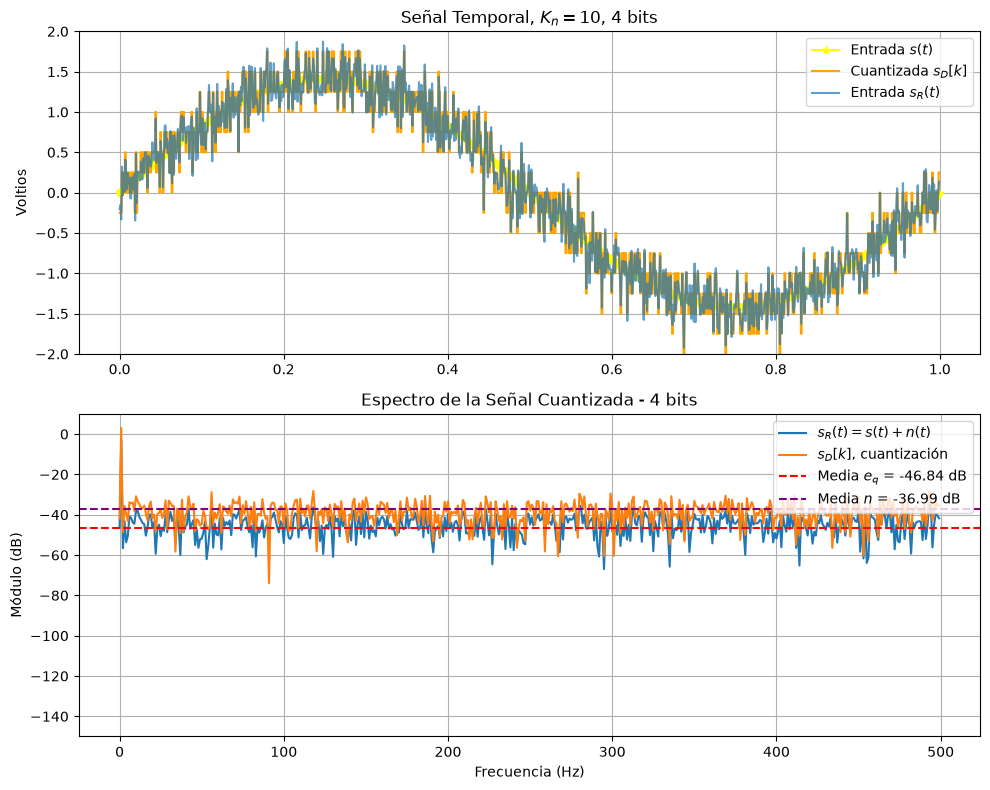

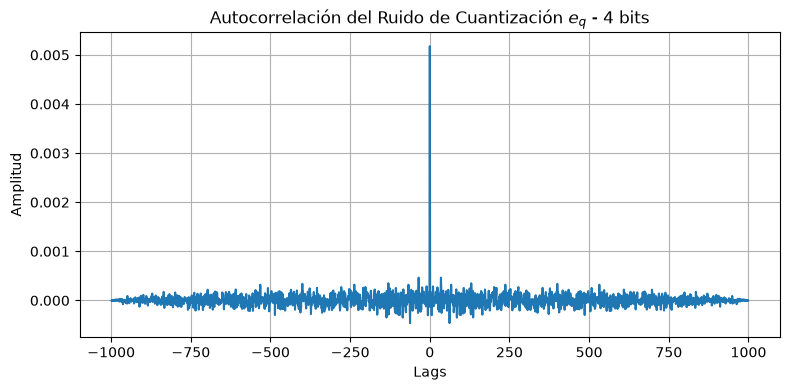

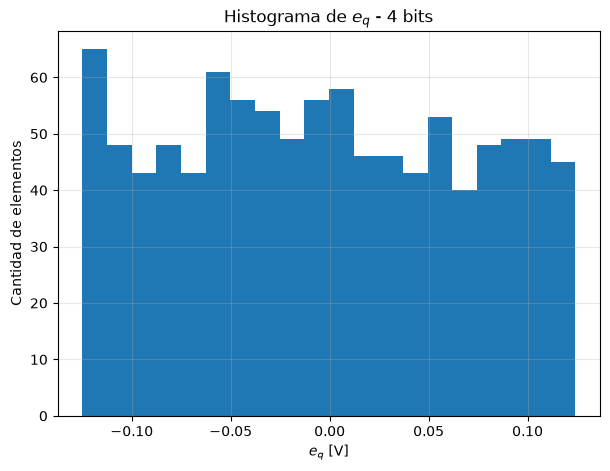


--- Análisis Estadístico ---
Varianza de e_q medida: 5.17e-03 V²
Varianza teórica Pq: 5.21e-03 V²
Estadístico KS: 0.0373
p-value: 0.1203
Resultado: No se rechaza H0. El ruido de cuantización es compatible con U(-q/2, q/2).
SNR Real del sistema: 12.66 dB

        SIMULACIÓN CON 8 BITS
q = 1.562500e-02 V
Pq teórica = 2.034505e-05 V²
Pn = 2.034505e-04 V²


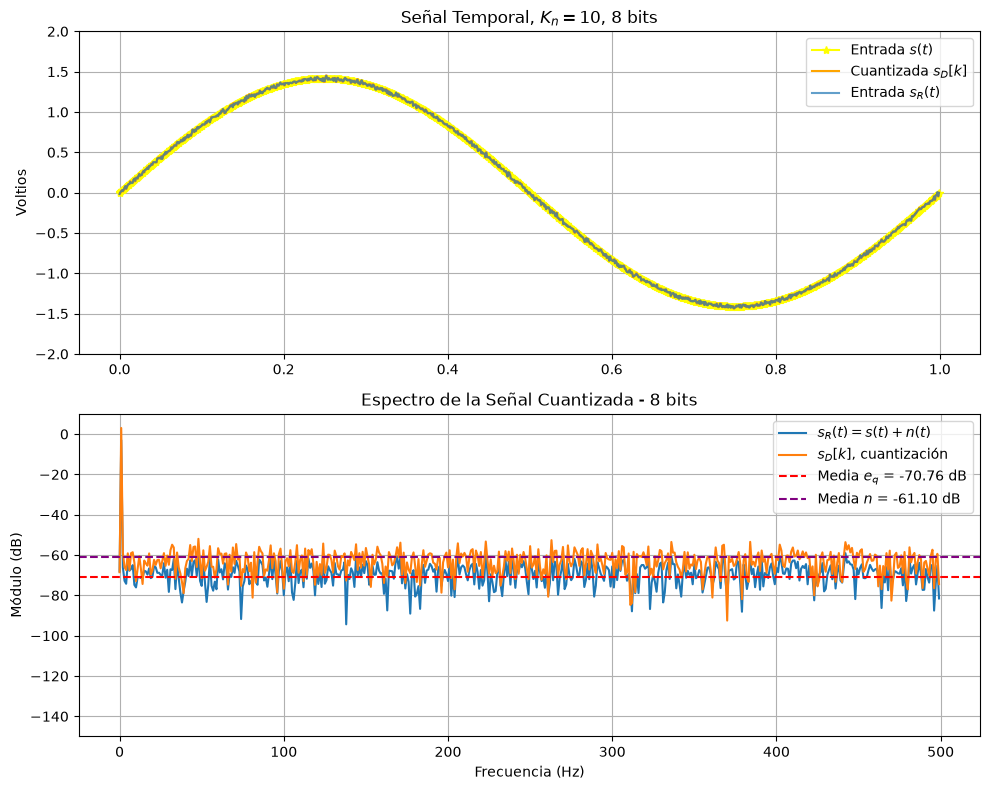

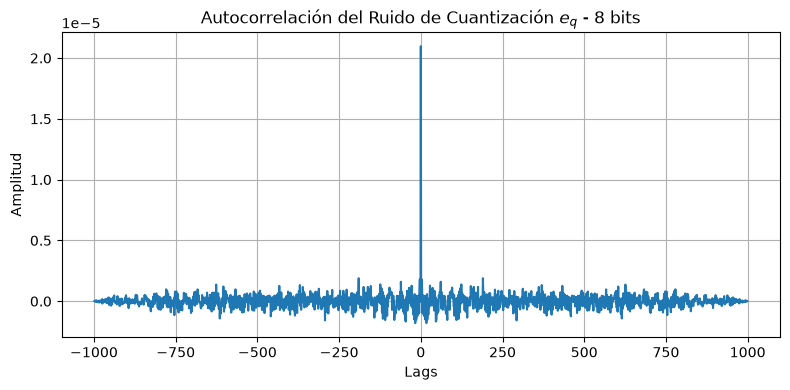

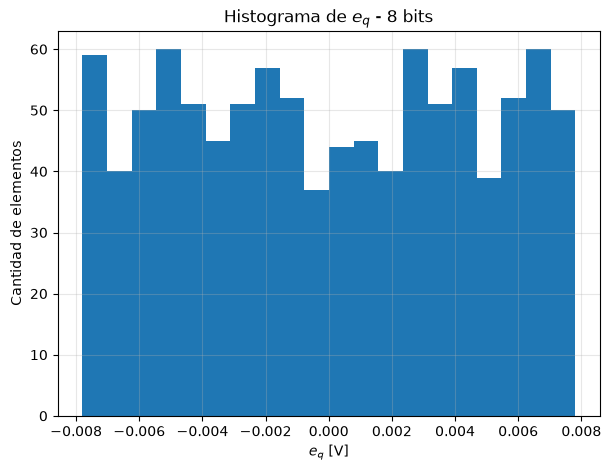


--- Análisis Estadístico ---
Varianza de e_q medida: 2.10e-05 V²
Varianza teórica Pq: 2.03e-05 V²
Estadístico KS: 0.0221
p-value: 0.7053
Resultado: No se rechaza H0. El ruido de cuantización es compatible con U(-q/2, q/2).
SNR Real del sistema: 36.87 dB

        SIMULACIÓN CON 16 BITS
q = 6.103516e-05 V
Pq teórica = 3.104409e-10 V²
Pn = 3.104409e-09 V²


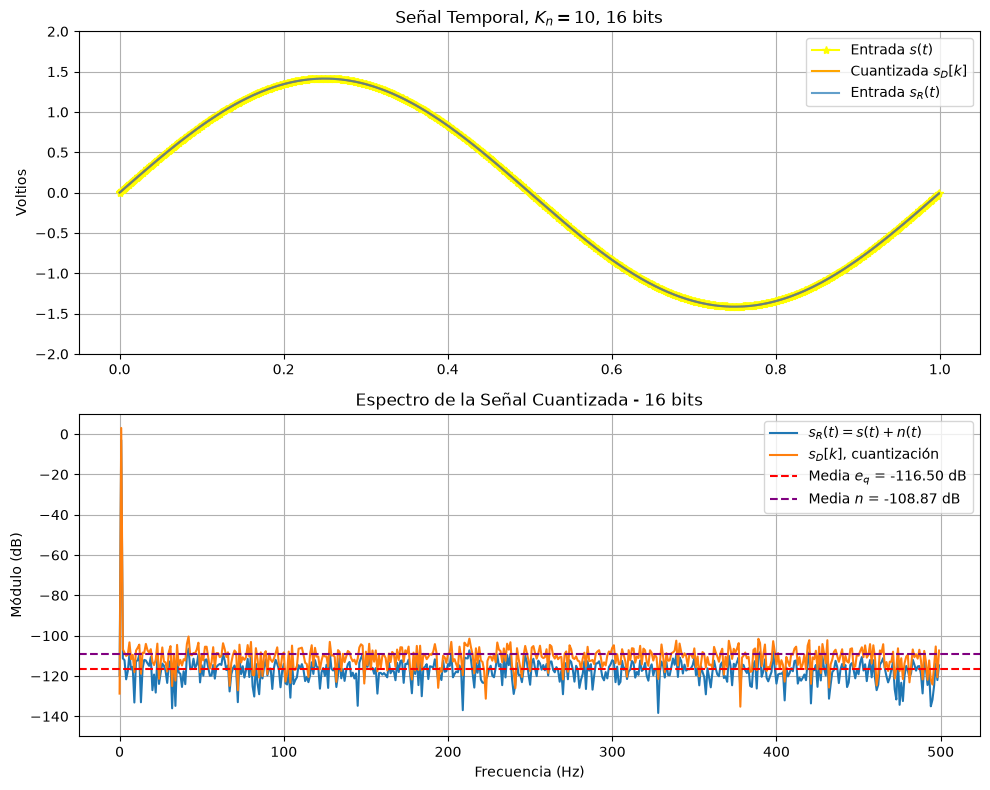

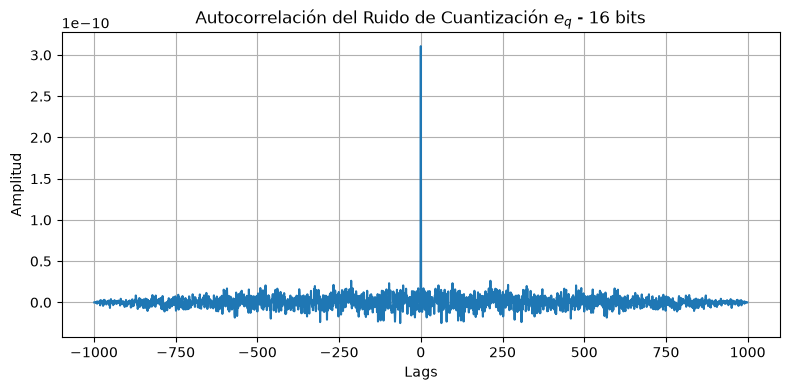

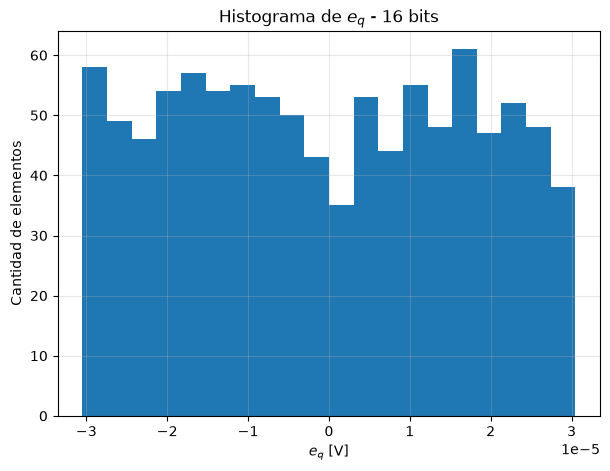


--- Análisis Estadístico ---
Varianza de e_q medida: 3.10e-10 V²
Varianza teórica Pq: 3.10e-10 V²
Estadístico KS: 0.0290
p-value: 0.3637
Resultado: No se rechaza H0. El ruido de cuantización es compatible con U(-q/2, q/2).
SNR Real del sistema: 84.85 dB


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import kstest


# %% 1. Definición de la función senoidal
def funcion_sen(A=1, Vmed=0, ff=1, phi=0, nn=1000, fs=1000):
    tt = np.arange(nn) / fs
    xx = A * np.sin(2 * np.pi * ff * tt + phi) + Vmed
    return tt, xx


# %% 2. Parámetros de la simulación
fs = 1000
N = 1000

B = [4, 8, 16]

Vf = 2.0
kn = 10
f0 = 1.0


# %% 3. Simulación para cada cantidad de bits
for b in B:

    print("\n======================================")
    print(f"        SIMULACIÓN CON {b} BITS")
    print("======================================")

    # Paso de cuantización
    q = (2 * Vf) / (2**b)

    # Potencia teórica del ruido de cuantización
    Pq = (q**2) / 12

    # Potencia del ruido analógico
    Pn = kn * Pq

    print(f"q = {q:.6e} V")
    print(f"Pq teórica = {Pq:.6e} V²")
    print(f"Pn = {Pn:.6e} V²")


    # %% 4. Generación de la señal
    tt, s = funcion_sen(
        A=np.sqrt(2),
        Vmed=0,
        ff=f0,
        phi=0,
        nn=N,
        fs=fs
    )

    # Ruido analógico
    sigma_n = np.sqrt(Pn)
    n = np.random.normal(0, sigma_n, N)

    # Señal con ruido
    s_R = s + n

    # Saturación
    s_R_sat = np.clip(s_R, -Vf, Vf)

    # Cuantización
    s_D = np.round(s_R_sat / q) * q

    # Error de cuantización
    e_q = s_D - s_R


    # %% 5. Análisis espectral
    S_D = np.fft.fft(s_D) / N
    S_s = np.fft.fft(s) / N
    S_r = np.fft.fft(s_R) / N
    e = np.fft.fft(e_q) / N
    r = np.fft.fft(n) / N

    freqs = np.fft.fftfreq(N, 1/fs)

    # Frecuencias positivas
    half_N = N // 2

    S_D_onesided = S_D[:half_N].copy()
    S_s_onesided = S_s[:half_N].copy()
    S_r_onesided = S_r[:half_N].copy()
    e_onesided = e[:half_N].copy()
    r_onesided = r[:half_N].copy()

    freqs_oneside = freqs[:half_N]

    # Corrección de amplitud unilateral
    S_D_onesided[1:] *= 2
    S_s_onesided[1:] *= 2
    e_onesided[1:] *= 2
    r_onesided[1:] *= 2

    # Módulos en dB
    mod_S_D_dB = 20 * np.log10(np.abs(S_D_onesided) + 1e-12)
    mod_S_s_dB = 20 * np.log10(np.abs(S_s_onesided) + 1e-12)
    mod_S_r_dB = 20 * np.log10(np.abs(S_r_onesided) + 1e-12)
    mod_r_dB = 20 * np.log10(np.abs(r_onesided) + 1e-12)
    mod_e_dB = 20 * np.log10(np.abs(e_onesided) + 1e-12)

    # Promedio espectral correcto (sobre la potencia media)
    mediaq = 10 * np.log10(np.mean(np.abs(e_onesided)**2) + 1e-12)
    mediar = 10 * np.log10(np.mean(np.abs(r_onesided)**2) + 1e-12)


    # %% 6. Visualización temporal y espectral
    plt.figure(figsize=(10, 8))

    # ----- Señal temporal -----
    plt.subplot(2, 1, 1)
    plt.plot(tt, s, label='Entrada $s(t)$', color="yellow", marker='*')
    plt.step(tt, s_D, where='mid', label='Cuantizada $s_D[k]$', color='orange')
    plt.plot(tt, s_R, label='Entrada $s_R(t)$', alpha=0.7)
    plt.title(f"Señal Temporal, $K_n={kn}$, {b} bits")
    plt.ylabel('Voltios')
    plt.legend(loc='upper right')
    plt.grid(True)
    plt.ylim(-Vf, Vf)

    # ----- Espectro -----
    plt.subplot(2, 1, 2)
    plt.plot(freqs_oneside, mod_S_r_dB, label='$s_R(t)=s(t)+n(t)$')
    plt.plot(freqs_oneside, mod_S_D_dB, label='$s_D[k]$, cuantización')
    plt.axhline(mediaq, linestyle='--', color='red', label=f"Media $e_q$ = {mediaq:.2f} dB")
    plt.axhline(mediar, linestyle='--', color='purple', label=f"Media $n$ = {mediar:.2f} dB")

    plt.title(f"Espectro de la Señal Cuantizada - {b} bits")
    plt.xlabel('Frecuencia (Hz)')
    plt.ylabel('Módulo (dB)')
    plt.grid(True)
    plt.legend(loc='upper right')
    plt.ylim(-150, 10)
    plt.tight_layout()
    plt.show()


    # %% 7. Autocorrelación del ruido de cuantización
    plt.figure(figsize=(8, 4))

    r_eq = np.correlate(e_q, e_q, mode='full') / N
    lags = np.arange(-N + 1, N)

    plt.plot(lags, r_eq)
    plt.title(f'Autocorrelación del Ruido de Cuantización $e_q$ - {b} bits')
    plt.xlabel('Lags')
    plt.ylabel('Amplitud')
    plt.grid(True)

    plt.tight_layout()
    plt.show()


    # %% 8. Histograma del error de cuantización
    plt.figure(figsize=(7, 5))

    plt.hist(e_q, bins=20)
    plt.xlabel('$e_q$ [V]')
    plt.ylabel('Cantidad de elementos')
    plt.title(f'Histograma de $e_q$ - {b} bits')
    plt.grid(True, alpha=0.3)

    plt.show()


    # %% 9. Test de Kolmogorov-Smirnov
    resultado = kstest(e_q, 'uniform', args=(-q/2, q))

    print("\n--- Análisis Estadístico ---")
    print(f"Varianza de e_q medida: {np.var(e_q):.2e} V²")
    print(f"Varianza teórica Pq: {Pq:.2e} V²")
    print(f"Estadístico KS: {resultado.statistic:.4f}")
    print(f"p-value: {resultado.pvalue:.4f}")

    if resultado.pvalue > 0.05:
        print(
            "Resultado: No se rechaza H0. "
            "El ruido de cuantización es compatible con U(-q/2, q/2)."
        )
    else:
        print(
            "Resultado: Se rechaza H0. "
            "El ruido de cuantización NO es uniforme al nivel de significancia del 5%."
        )


    # %% 10. SNR
    e_total = s_D - s
    P_s = np.mean(s**2)
    P_e_total = np.mean(e_total**2)

    SNR_real = 10 * np.log10(P_s / P_e_total)

    print(f"SNR Real del sistema: {SNR_real:.2f} dB")

<b> Análisis: </b>


Al analizar el comportamiento del ruido en comparación a la entrada según la cantidad de bits y el ruido de cuantización, se puede observar que a mayor cantidad de bits menor cantidad de ruido (Mayor similitud entre la señal de entrada y la digitalizada), en consecuencia mejor SNR.
Para analizar si cada bit se está usando efectivamente, usamos la relación de que cada bit me aporta 6 dB en el SNR.
$$
\begin{aligned}
\text{SNR}_{\text{4 bits}} &= 12.66 \text{ dB} \\
\text{SNR}_{\text{8 bits}} &= 36.87 \text{ dB} \\
\text{SNR}_{\text{16 bits}} &= 84.85 \text{ dB}
\end{aligned}
$$
Se puede ver que los bits no se usan efectivamente, ya que aportan menos que 6.02 dB/bit en el SNR , eso nos habla de que cuando la relación entre la potencia de ruido analógico y la potencia de cuantización es de 10, los bits no se usan efectivamente independientemente de su cantidad.
También se ve que el error de cuantización describe una distribución uniforme y su correlación nos da una delta con el valor de la energía, demostrando que seguimos estando ante un ruido blanco.

<b> Caso 3: $k_n=0.1$  b={4, 8, 16} </b>


        SIMULACIÓN CON 4 BITS
q = 2.500000e-01 V
Pq teórica = 5.208333e-03 V²
Pn = 5.208333e-04 V²


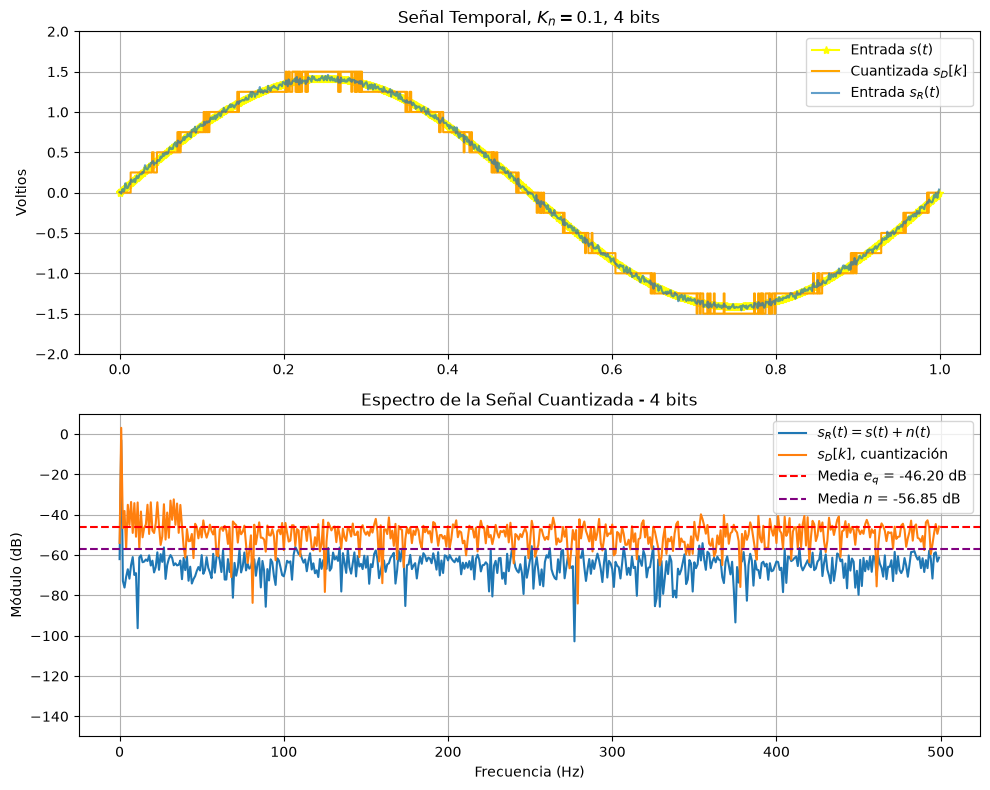

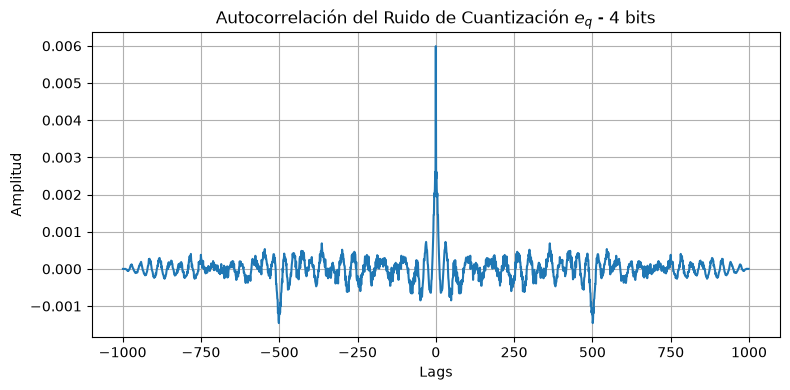

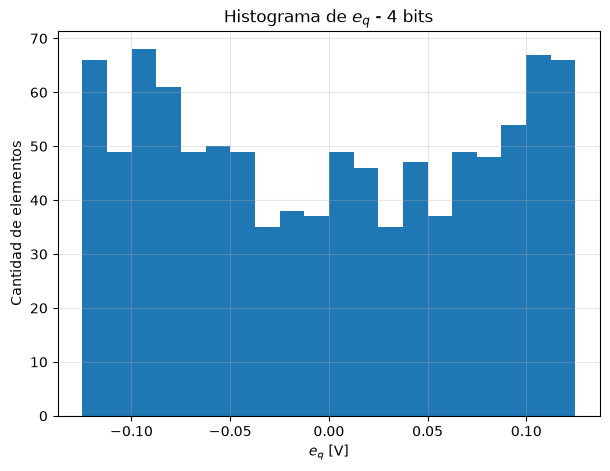


--- Análisis Estadístico ---
Varianza de e_q medida: 5.99e-03 V²
Varianza teórica Pq: 5.21e-03 V²
Estadístico KS: 0.0542
p-value: 0.0054
Resultado: Se rechaza H0. El ruido de cuantización NO es uniforme al nivel de significancia del 5%.
SNR Real del sistema: 21.73 dB

        SIMULACIÓN CON 8 BITS
q = 1.562500e-02 V
Pq teórica = 2.034505e-05 V²
Pn = 2.034505e-06 V²


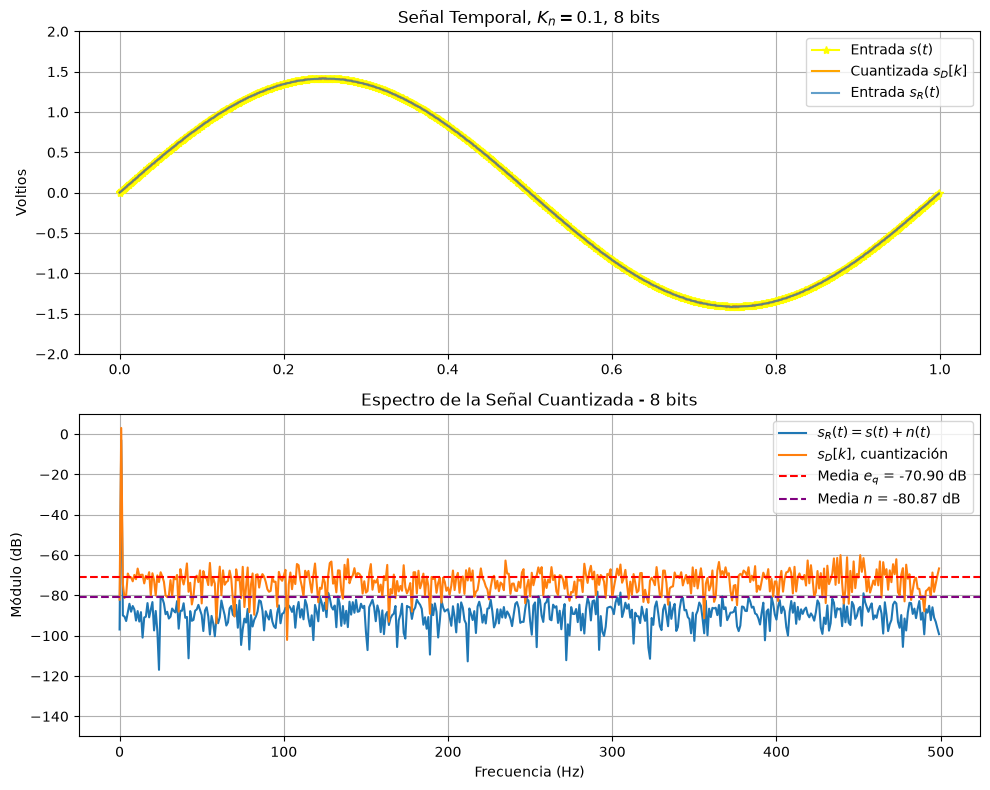

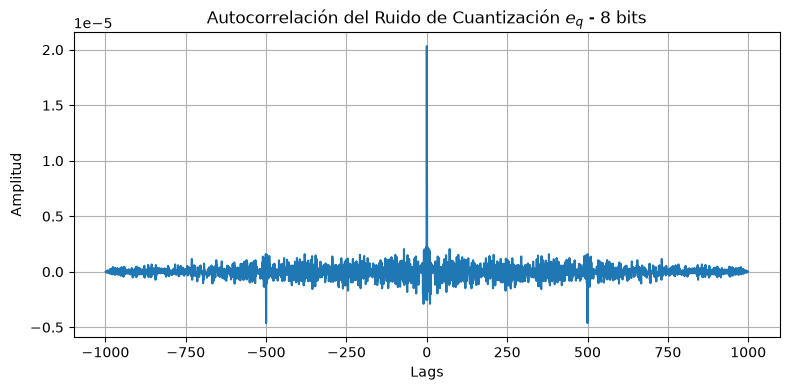

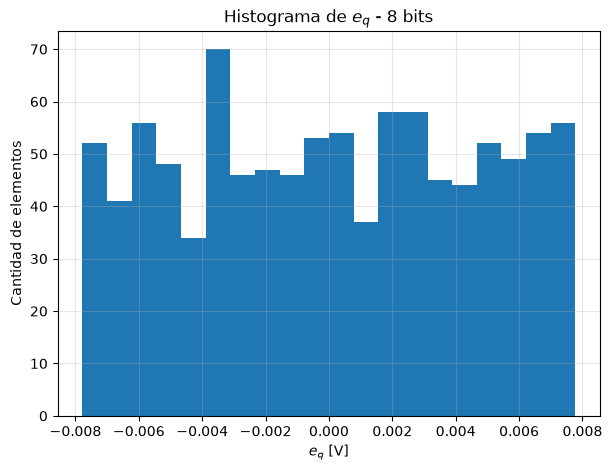


--- Análisis Estadístico ---
Varianza de e_q medida: 2.03e-05 V²
Varianza teórica Pq: 2.03e-05 V²
Estadístico KS: 0.0212
p-value: 0.7507
Resultado: No se rechaza H0. El ruido de cuantización es compatible con U(-q/2, q/2).
SNR Real del sistema: 46.26 dB

        SIMULACIÓN CON 16 BITS
q = 6.103516e-05 V
Pq teórica = 3.104409e-10 V²
Pn = 3.104409e-11 V²


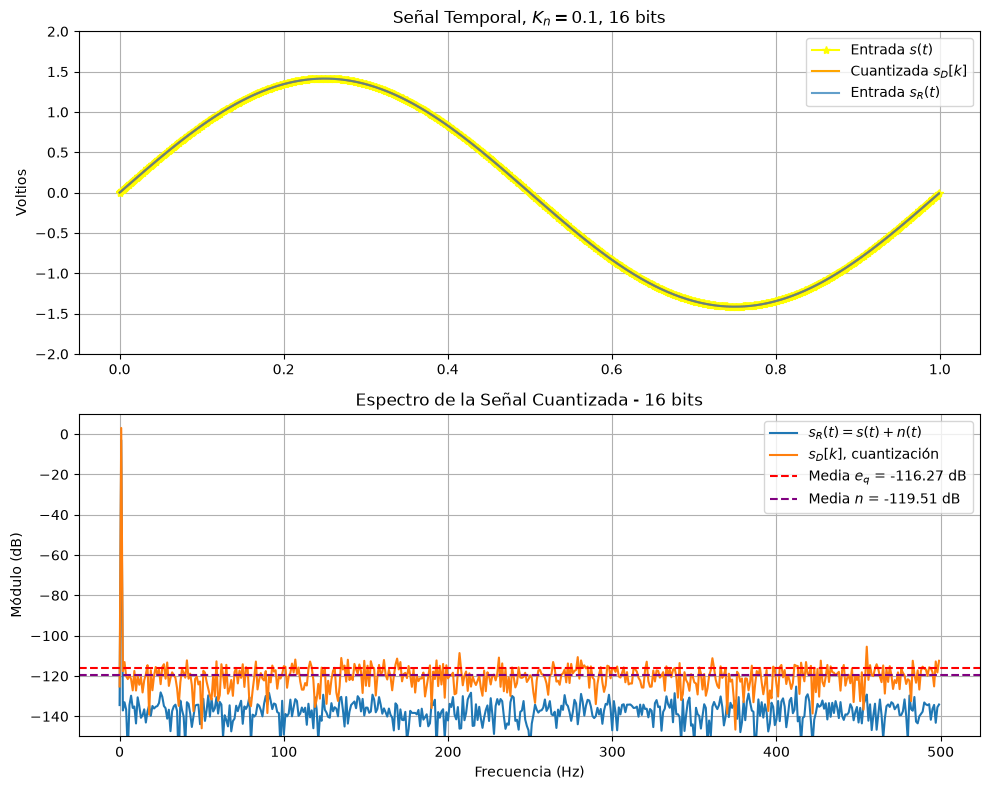

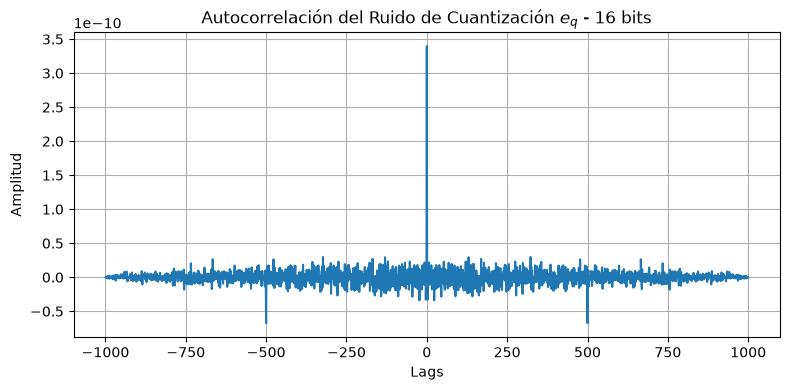

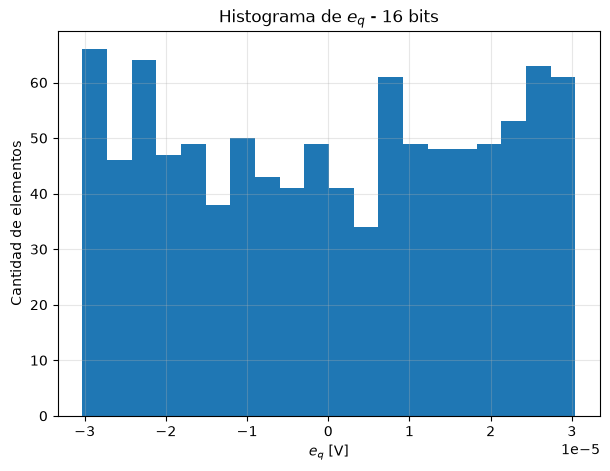


--- Análisis Estadístico ---
Varianza de e_q medida: 3.40e-10 V²
Varianza teórica Pq: 3.10e-10 V²
Estadístico KS: 0.0338
p-value: 0.1977
Resultado: No se rechaza H0. El ruido de cuantización es compatible con U(-q/2, q/2).
SNR Real del sistema: 94.16 dB


In [3]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import kstest


# %% 1. Definición de la función senoidal
def funcion_sen(A=1, Vmed=0, ff=1, phi=0, nn=1000, fs=1000):
    tt = np.arange(nn) / fs
    xx = A * np.sin(2 * np.pi * ff * tt + phi) + Vmed
    return tt, xx


# %% 2. Parámetros de la simulación
fs = 1000
N = 1000

B = [4, 8, 16]

Vf = 2.0
kn = 0.1
f0 = 1.0


# %% 3. Simulación para cada cantidad de bits
for b in B:

    print("\n======================================")
    print(f"        SIMULACIÓN CON {b} BITS")
    print("======================================")

    # Paso de cuantización
    q = (2 * Vf) / (2**b)

    # Potencia teórica del ruido de cuantización
    Pq = (q**2) / 12

    # Potencia del ruido analógico
    Pn = kn * Pq

    print(f"q = {q:.6e} V")
    print(f"Pq teórica = {Pq:.6e} V²")
    print(f"Pn = {Pn:.6e} V²")


    # %% 4. Generación de la señal
    tt, s = funcion_sen(
        A=np.sqrt(2),
        Vmed=0,
        ff=f0,
        phi=0,
        nn=N,
        fs=fs
    )

    # Ruido analógico
    sigma_n = np.sqrt(Pn)
    n = np.random.normal(0, sigma_n, N)

    # Señal con ruido
    s_R = s + n

    # Saturación
    s_R_sat = np.clip(s_R, -Vf, Vf)

    # Cuantización
    s_D = np.round(s_R_sat / q) * q

    # Error de cuantización
    e_q = s_D - s_R


    # %% 5. Análisis espectral
    S_D = np.fft.fft(s_D) / N
    S_s = np.fft.fft(s) / N
    S_r = np.fft.fft(s_R) / N
    e = np.fft.fft(e_q) / N
    r = np.fft.fft(n) / N

    freqs = np.fft.fftfreq(N, 1/fs)

    # Frecuencias positivas
    half_N = N // 2

    S_D_onesided = S_D[:half_N].copy()
    S_s_onesided = S_s[:half_N].copy()
    S_r_onesided = S_r[:half_N].copy()
    e_onesided = e[:half_N].copy()
    r_onesided = r[:half_N].copy()

    freqs_oneside = freqs[:half_N]

    # Corrección de amplitud unilateral
    S_D_onesided[1:] *= 2
    S_s_onesided[1:] *= 2
    e_onesided[1:] *= 2
    r_onesided[1:] *= 2

    # Módulos en dB
    mod_S_D_dB = 20 * np.log10(np.abs(S_D_onesided) + 1e-12)
    mod_S_s_dB = 20 * np.log10(np.abs(S_s_onesided) + 1e-12)
    mod_S_r_dB = 20 * np.log10(np.abs(S_r_onesided) + 1e-12)
    mod_r_dB = 20 * np.log10(np.abs(r_onesided) + 1e-12)
    mod_e_dB = 20 * np.log10(np.abs(e_onesided) + 1e-12)

    # Promedio espectral correcto (sobre la potencia media)
    mediaq = 10 * np.log10(np.mean(np.abs(e_onesided)**2) + 1e-12)
    mediar = 10 * np.log10(np.mean(np.abs(r_onesided)**2) + 1e-12)


    # %% 6. Visualización temporal y espectral
    plt.figure(figsize=(10, 8))

    # ----- Señal temporal -----
    plt.subplot(2, 1, 1)
    plt.plot(tt, s, label='Entrada $s(t)$', color="yellow", marker='*')
    plt.step(tt, s_D, where='mid', label='Cuantizada $s_D[k]$', color='orange')
    plt.plot(tt, s_R, label='Entrada $s_R(t)$', alpha=0.7)
    plt.title(f"Señal Temporal, $K_n={kn}$, {b} bits")
    plt.ylabel('Voltios')
    plt.legend(loc='upper right')
    plt.grid(True)
    plt.ylim(-Vf, Vf)

    # ----- Espectro -----
    plt.subplot(2, 1, 2)
    plt.plot(freqs_oneside, mod_S_r_dB, label='$s_R(t)=s(t)+n(t)$')
    plt.plot(freqs_oneside, mod_S_D_dB, label='$s_D[k]$, cuantización')
    plt.axhline(mediaq, linestyle='--', color='red', label=f"Media $e_q$ = {mediaq:.2f} dB")
    plt.axhline(mediar, linestyle='--', color='purple', label=f"Media $n$ = {mediar:.2f} dB")

    plt.title(f"Espectro de la Señal Cuantizada - {b} bits")
    plt.xlabel('Frecuencia (Hz)')
    plt.ylabel('Módulo (dB)')
    plt.grid(True)
    plt.legend(loc='upper right')
    plt.ylim(-150, 10)
    plt.tight_layout()
    plt.show()


    # %% 7. Autocorrelación del ruido de cuantización
    plt.figure(figsize=(8, 4))

    r_eq = np.correlate(e_q, e_q, mode='full') / N
    lags = np.arange(-N + 1, N)

    plt.plot(lags, r_eq)
    plt.title(f'Autocorrelación del Ruido de Cuantización $e_q$ - {b} bits')
    plt.xlabel('Lags')
    plt.ylabel('Amplitud')
    plt.grid(True)

    plt.tight_layout()
    plt.show()


    # %% 8. Histograma del error de cuantización
    plt.figure(figsize=(7, 5))

    plt.hist(e_q, bins=20)
    plt.xlabel('$e_q$ [V]')
    plt.ylabel('Cantidad de elementos')
    plt.title(f'Histograma de $e_q$ - {b} bits')
    plt.grid(True, alpha=0.3)

    plt.show()


    # %% 9. Test de Kolmogorov-Smirnov
    resultado = kstest(e_q, 'uniform', args=(-q/2, q))

    print("\n--- Análisis Estadístico ---")
    print(f"Varianza de e_q medida: {np.var(e_q):.2e} V²")
    print(f"Varianza teórica Pq: {Pq:.2e} V²")
    print(f"Estadístico KS: {resultado.statistic:.4f}")
    print(f"p-value: {resultado.pvalue:.4f}")

    if resultado.pvalue > 0.05:
        print(
            "Resultado: No se rechaza H0. "
            "El ruido de cuantización es compatible con U(-q/2, q/2)."
        )
    else:
        print(
            "Resultado: Se rechaza H0. "
            "El ruido de cuantización NO es uniforme al nivel de significancia del 5%."
        )


    # %% 10. SNR
    e_total = s_D - s
    P_s = np.mean(s**2)
    P_e_total = np.mean(e_total**2)

    SNR_real = 10 * np.log10(P_s / P_e_total)

    print(f"SNR Real del sistema: {SNR_real:.2f} dB")

<b> Análisis: </b>


Al analizar el comportamiento del ruido en comparación a la entrada según la cantidad de bits y el ruido de cuantización, se puede observar que a mayor cantidad de bits menor cantidad de ruido (Mayor similitud entre la señal de entrada y la digitalizada), en consecuencia mejor SNR.
Para analizar si cada bit se está usando efectivamente, usamos la relación de que cada bit me aporta 6 dB en el SNR.
$$
\begin{aligned}
\text{SNR}_{\text{4 bits}} &= 21.73 \text{ dB} \\
\text{SNR}_{\text{8 bits}} &= 46.26 \text{ dB} \\
\text{SNR}_{\text{16 bits}} &= 94.16 \text{ dB}
\end{aligned}
$$
Se puede ver que los bits se usan efectivamente, ya que los bits aportan aproximadamente 6dB cada uno en el SNR. 
También se ve que el error de cuantización describe una distribución uniforme y una delta en la autocorrelación del ruido de cuantización en los casos de 8 y 16 bits, mientras que en el caso de 4 bits no, se rechaza la hipótesis.

### Tabla 1: Efecto teórico según la potencia del ruido analógico ($P_n = K_n \cdot P_q$)

| Bits ($B$) | Paso de Cuantización ($q$) | (Ideal) | $K_n = 0.1$ | $K_n = 1$ | $K_n = 10$ |
| :---: | :---: | :---: | :---: | :---: | :---: |
| **4**  | $0.2500 \text{ V}$   | $22.83 \text{ dB}$ | $21.73 \text{ dB}$ | $19.47 \text{ dB}$ | $12.66 \text{ dB}$ |
| **8** | $0.0156 \text{ V}$   | $46.91 \text{ dB}$ | $46.26 \text{ dB}$ | $44.09 \text{ dB}$ | $36.87 \text{ dB}$ |
| **16** | $0.000061 \text{ V}$   | $95.07 \text{ dB}$ | $92.09 \text{ dB}$ | $92.06 \text{ dB}$ | $84.85 \text{ dB}$ |


<b>Análisis:</b>
Se puede ver que el caso con menor SNR en relación a la cantidad de bits es $$K_n=10$$ y el que tiene un SNR más cercano al ideal es $$K_n=0.1$$, dejando como conclusión que mayor cantidad de bits no me da necesariamente un resultado óptimo siempre. Hay que analizar otros factores como la relación entre el ruido analógico y el de cuantización, no tiene sentido aumentar la cantidad de bits si la relación SNR no va a aumentar una cantidad óptima (ya que estos no van a ser aprovechados).
De igual forma se observa que en el caso de kn=1, se acerca más al ideal cuand los bits son más, mientras que para kn=10 aunque aumente los bits sigue teniendo un SNR lejos del ideal.
Por eso es importante analizar cual es la potencia de ruido antes de elegir la cantidad de bits 


<b>Conclusión:</b>
En este trabajo se analizó el comportamiento del ruido blanco, en un ADC, como es su distribución (uniforme) y como este es incorrelado através de su autocorrelación, describiendo una delta de dirac en la frecuencia. Además se vio como afecta la relación de la P_n (ruido analógico) con la Pq y como la relación señal ruido es mayor cuando $$P_n=0.1P_q$$, dejando en claro que es necesario analizar este factor antes de elegir una cantidad de bits, para que estos no sean desaprovechados.